# Seleksi Data Science Academy COMPFEST 18
> Langkah: EDA, uji normalitas, korelasi antar dan intrafitur, rekayasa fitur, SHAP, lightGBM + optuna  
> Metric: RMSE on `property_organic_content`  
> Perubahan: Transformasi log di target, LightGBM dengan NaN handling, SHAP kumulatif 95%, Optuna Bayesian search

In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, gaussian_kde
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'savefig.dpi': 150,
    'savefig.bbox': 'tight', 'axes.grid': True,
    'grid.alpha': 0.3,
})

TARGET = 'property_organic_content'
SEED   = 42
os.makedirs('outputs', exist_ok=True)
print('Imports ok')

Imports ok


c:\Users\visco\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
train = pd.read_csv("dataset/train.csv")
test  = pd.read_csv("dataset/test.csv")

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (11210, 52)  |  Test: (2670, 51)


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis (EDA)
### 2.1 Structure Audit

In [3]:
# Pisahin numerik & kategorik
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = [
    'source_id', 'sampling_strategy', 'geo_zone_macro', 
    'geo_zone_meso', 'geo_zone_micro', 'land_cover_type', 
    'biome', 'parent_rock_type'
]
feat_cols_num = [c for c in num_cols if c != TARGET]

print(f'Fitur numerik di train: {len(feat_cols_num)}')
print(f'Tabel kategorik di train: {len(cat_cols)}')

for c in cat_cols:
    print(f'\n{c} ({train[c].nunique()} unique):')
    print(train[c].value_counts().to_string())
    
print()

# Cari nilai null
null_train = train.isnull().sum()
null_test  = test.isnull().sum()
null_df = pd.DataFrame({
    'null_train': null_train,
    'pct_train':  (null_train / len(train) * 100).round(2),
    'null_test':  null_test,
    'pct_test':   (null_test  / len(test)  * 100).round(2),
})
null_df = null_df[null_df['null_train'] > 0].sort_values('null_train', ascending=False)
print('Kolom dengan null')
print(null_df.to_string())

Fitur numerik di train: 39
Tabel kategorik di train: 8

source_id (35 unique):
source_id
Source_01    3986
Source_02    2926
Source_05     583
Source_06     515
Source_07     502
Source_04     398
Source_09     312
Source_08     231
Source_10     185
Source_11     169
Source_13     151
Source_12     149
Source_15     130
Source_14     122
Source_16     119
Source_18     103
Source_19     102
Source_21      81
Source_25      66
Source_26      56
Source_24      52
Source_28      49
Source_29      47
Source_31      40
Source_32      32
Source_20      29
Source_33      15
Source_35      12
Source_37      10
Source_34      10
Source_36       8
Source_39       6
Source_44       5
Source_43       5
Source_46       4

sampling_strategy (3 unique):
sampling_strategy
Auger      9824
Profile    1068
Unknown     318

geo_zone_macro (5 unique):
geo_zone_macro
SE    5767
MW    2930
S     1022
N      979
NE     512

geo_zone_meso (23 unique):
geo_zone_meso
State_01    4835
State_02    1750
State_04  

### 2.2 Target Distribution

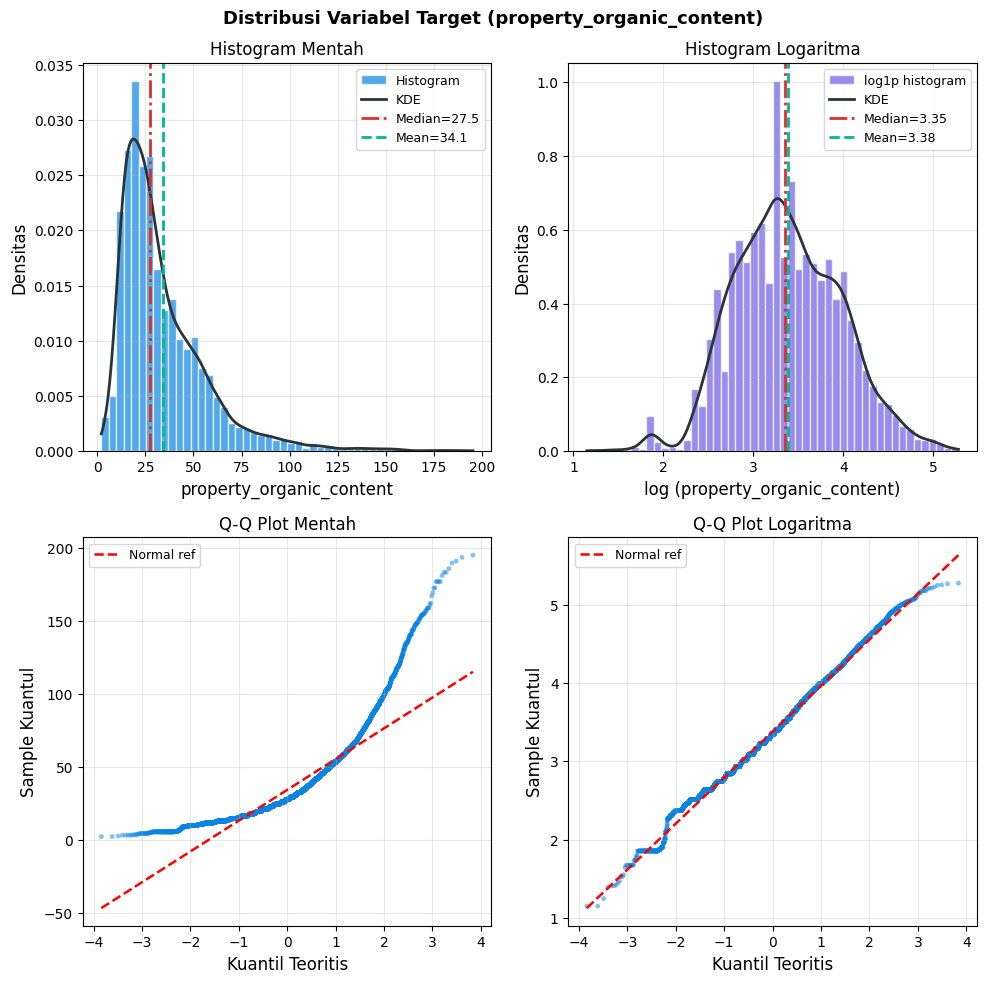

Skewness (mentah): 2.0278
Skewness (log): 0.1420
Kurtosis (mentah): 6.0820
Kurtosis (log): -0.0362
Min/Max (mentah): 2.16 / 195.23
Min/Max (log): 1.15 / 5.28


In [4]:
tsb = train[TARGET].dropna()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Distribusi Variabel Target (property_organic_content)', fontweight='bold', fontsize=13)

axes = axes.flatten()

# Histogram & KDE mentah
ax = axes[0]
ax.hist(tsb, bins=50, density=True, color='#0984e3', alpha=0.7, edgecolor='white', label='Histogram')
kde = gaussian_kde(tsb)
x = np.linspace(tsb.min(), tsb.max(), 400)
ax.plot(x, kde(x), color='#2d3436', lw=2, label='KDE')
ax.axvline(tsb.median(), color='#d63031', ls='-.', lw=2, label=f'Median={tsb.median():.1f}')
ax.axvline(tsb.mean(),   color='#00b894', ls='--', lw=2, label=f'Mean={tsb.mean():.1f}')
ax.set_xlabel('property_organic_content'); ax.set_ylabel('Densitas')
ax.set_title('Histogram Mentah'); ax.legend(fontsize=9)

# Transformasi log
ax = axes[1]
log_tsb = np.log1p(tsb)
ax.hist(log_tsb, bins=50, density=True, color='#6c5ce7', alpha=0.7, edgecolor='white', label='log1p histogram')
kde2 = gaussian_kde(log_tsb)
x2 = np.linspace(log_tsb.min(), log_tsb.max(), 400)
ax.plot(x2, kde2(x2), color='#2d3436', lw=2, label='KDE')
ax.axvline(log_tsb.median(), color='#d63031', ls='-.', lw=2, label=f'Median={log_tsb.median():.2f}')
ax.axvline(log_tsb.mean(),   color='#00b894', ls='--', lw=2, label=f'Mean={log_tsb.mean():.2f}')
ax.set_xlabel('log (property_organic_content)'); ax.set_ylabel('Densitas')
ax.set_title('Histogram Logaritma'); ax.legend(fontsize=9)

# Q-Q plot mentah
ax = axes[2]
(osm, osr), (slope, intercept, _) = stats.probplot(tsb, dist='norm')
ax.scatter(osm, osr, s=12, alpha=0.5, color='#0984e3', edgecolors='none')
ax.plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
        'r--', lw=1.8, label='Normal ref')
ax.set_xlabel('Kuantil Teoritis'); ax.set_ylabel('Sample Kuantul')
ax.set_title('Q-Q Plot Mentah')
ax.legend(fontsize=9)

# Q-Q plot log
ax = axes[3]
(osm, osr), (slope, intercept, _) = stats.probplot(log_tsb, dist='norm')
ax.scatter(osm, osr, s=12, alpha=0.5, color='#0984e3', edgecolors='none')
ax.plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
        'r--', lw=1.8, label='Normal ref')
ax.set_xlabel('Kuantil Teoritis'); ax.set_ylabel('Sample Kuantul')
ax.set_title('Q-Q Plot Logaritma')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/01_target_distribution.png')
plt.show()

print(f'Skewness (mentah): {tsb.skew():.4f}')
print(f'Skewness (log): {log_tsb.skew():.4f}')
print(f'Kurtosis (mentah): {tsb.kurt():.4f}')
print(f'Kurtosis (log): {log_tsb.kurt():.4f}')
print(f'Min/Max (mentah): {tsb.min():.2f} / {tsb.max():.2f}')
print(f'Min/Max (log): {log_tsb.min():.2f} / {log_tsb.max():.2f}')

### 2.3 Feature Skewness

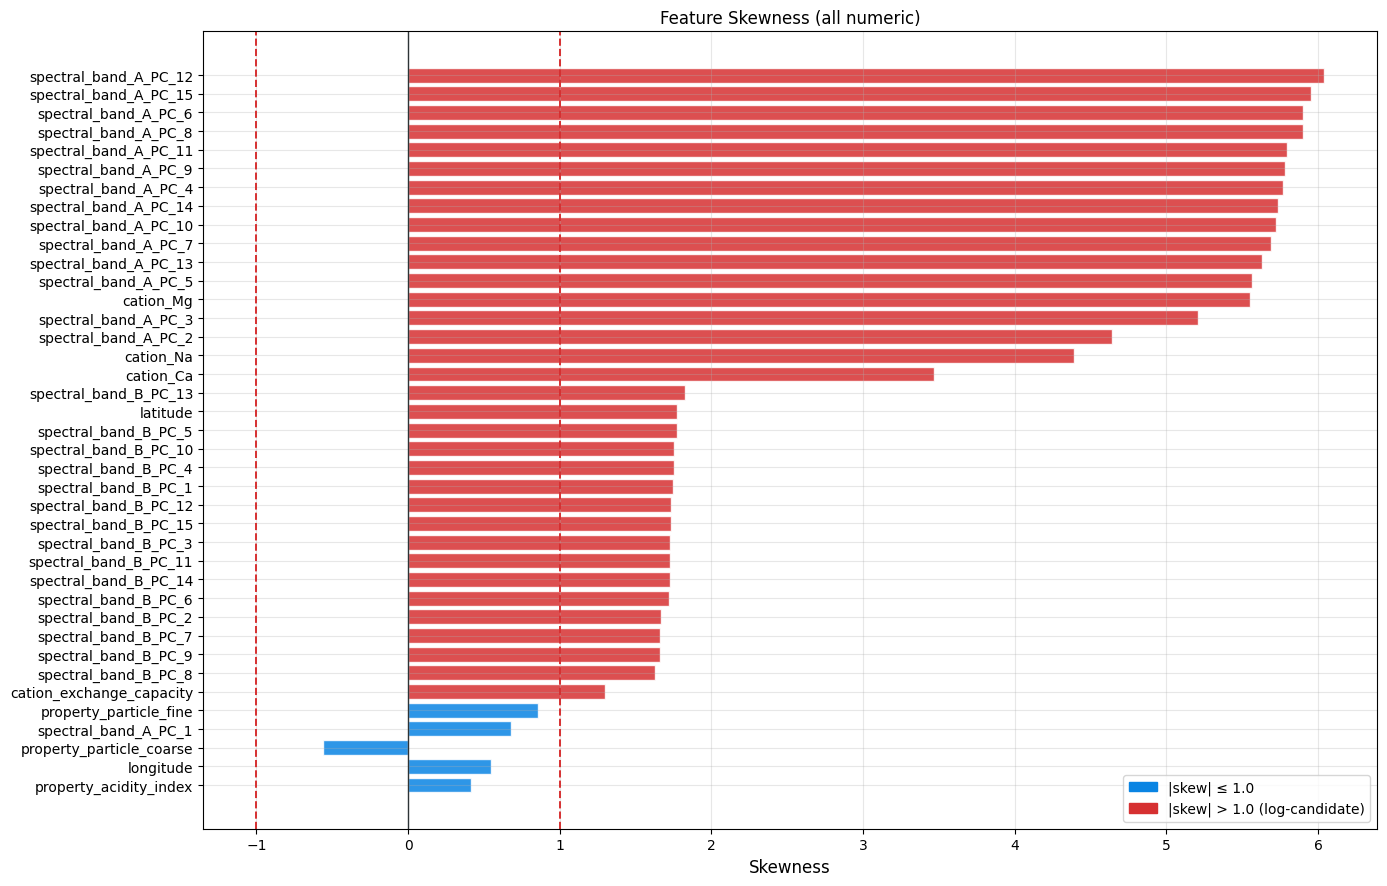

Log-transform candidates (34): ['spectral_band_A_PC_12', 'spectral_band_A_PC_15', 'spectral_band_A_PC_6', 'spectral_band_A_PC_8', 'spectral_band_A_PC_11', 'spectral_band_A_PC_9', 'spectral_band_A_PC_4', 'spectral_band_A_PC_14', 'spectral_band_A_PC_10', 'spectral_band_A_PC_7', 'spectral_band_A_PC_13', 'spectral_band_A_PC_5', 'cation_Mg', 'spectral_band_A_PC_3', 'spectral_band_A_PC_2', 'cation_Na', 'cation_Ca', 'spectral_band_B_PC_13', 'latitude', 'spectral_band_B_PC_5', 'spectral_band_B_PC_10', 'spectral_band_B_PC_4', 'spectral_band_B_PC_1', 'spectral_band_B_PC_12', 'spectral_band_B_PC_15', 'spectral_band_B_PC_3', 'spectral_band_B_PC_11', 'spectral_band_B_PC_14', 'spectral_band_B_PC_6', 'spectral_band_B_PC_2', 'spectral_band_B_PC_7', 'spectral_band_B_PC_9', 'spectral_band_B_PC_8', 'cation_exchange_capacity']


In [5]:
spec_A = [f'spectral_band_A_PC_{i}' for i in range(1, 16)]
spec_B = [f'spectral_band_B_PC_{i}' for i in range(1, 16)]
soil_feats = ['property_particle_coarse', 'property_particle_fine',
              'property_acidity_index', 'cation_Ca', 'cation_Mg',
              'cation_Na', 'cation_exchange_capacity', 'latitude', 'longitude']

all_num_feats = spec_A + spec_B + soil_feats
all_num_feats = [c for c in all_num_feats if c in train.columns]

skew_rows = []
for col in all_num_feats:
    s = float(train[col].skew())
    skew_rows.append({'feature': col, 'skewness': round(s,4),
                      'abs_skew': round(abs(s),4),
                      'flag': 'log-candidate' if abs(s) > 1.0 else ''})
skew_df = pd.DataFrame(skew_rows).sort_values('abs_skew', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
colors = ['#d63031' if abs(r) > 1.0 else '#0984e3' for r in skew_df['skewness']]
ax.barh(skew_df['feature'], skew_df['skewness'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0,   color='#2d3436', lw=1.0)
ax.axvline(1.0, color='#d63031', lw=1.4, ls='--')
ax.axvline(-1.0,color='#d63031', lw=1.4, ls='--')
ax.set_xlabel('Skewness')
ax.set_title('Feature Skewness (all numeric)')
ax.invert_yaxis()
p1 = mpatches.Patch(color='#0984e3', label='|skew| ≤ 1.0')
p2 = mpatches.Patch(color='#d63031', label='|skew| > 1.0 (log-candidate)')
ax.legend(handles=[p1, p2])
plt.tight_layout()
plt.savefig('outputs/02_feature_skewness.png')
plt.show()

flagged_feats = skew_df[skew_df['abs_skew'] > 1.0]['feature'].tolist()
print(f'Log-transform candidates ({len(flagged_feats)}): {flagged_feats}')

### 2.4 Missingness Structure

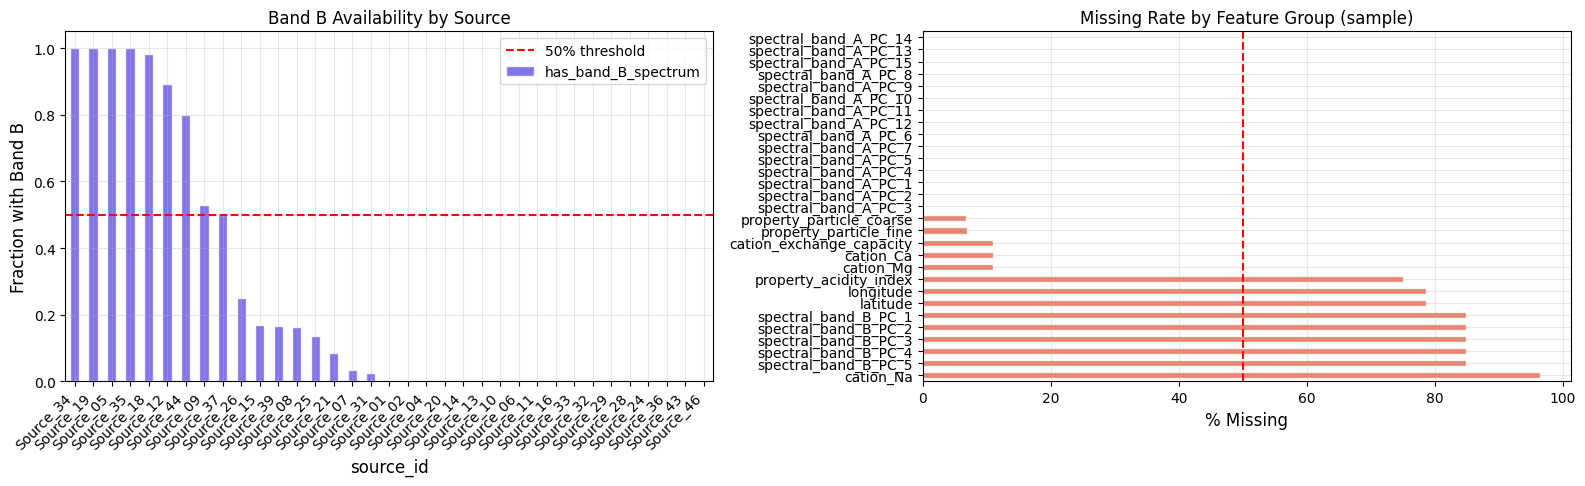

Band B total missing in train: 9516 / 11210
lat/lon missing: 8820 / 11210


In [6]:
# Band B availability by source_id
band_b_avail = train.groupby('source_id')['has_band_B_spectrum'].apply(
    lambda x: (x == 'YES').mean()
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
band_b_avail.plot(kind='bar', ax=ax, color='#6c5ce7', edgecolor='white', alpha=0.85)
ax.set_xlabel('source_id'); ax.set_ylabel('Fraction with Band B')
ax.set_title('Band B Availability by Source')
ax.axhline(0.5, color='red', ls='--', lw=1.5, label='50% threshold')
ax.legend(); ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Null heatmap summary
null_pct = (train[soil_feats + spec_A + spec_B[:5]].isnull().mean() * 100).sort_values(ascending=False)
ax = axes[1]
null_pct.plot(kind='barh', ax=ax, color='#e17055', edgecolor='white', alpha=0.85)
ax.set_xlabel('% Missing'); ax.set_title('Missing Rate by Feature Group (sample)')
ax.axvline(50, color='red', ls='--', lw=1.5)

plt.tight_layout()
plt.savefig('outputs/03_missingness.png')
plt.show()

print('Band B total missing in train:', train['spectral_band_B_PC_1'].isna().sum(), '/', len(train))
print('lat/lon missing:', train['latitude'].isna().sum(), '/', len(train))

## 3. Normality Tests
We use **Shapiro-Wilk** (n ≤ 5000 subsample) and **Kolmogorov-Smirnov** to determine whether Pearson or Spearman correlation is appropriate. For the target, both confirm right-skew → non-normal → **Spearman** is used throughout.

In [7]:
from scipy.stats import shapiro, kstest, skew as scipy_skew

results_norm = []
test_feats = [c for c in all_num_feats if train[c].notna().sum() > 30]

for col in [TARGET] + test_feats:
    data = train[col].dropna().values
    n    = len(data)
    # Shapiro-Wilk on subsample (max 5000 — SW is sensitive to n)
    subsample = data[np.random.choice(len(data), min(5000, len(data)), replace=False)]
    sw_stat, sw_p = shapiro(subsample)
    # KS test
    mu, sigma = data.mean(), data.std(ddof=1)
    ks_stat, ks_p = kstest(data, 'norm', args=(mu, sigma))
    
    results_norm.append({
        'feature': col,
        'n': n,
        'mean': round(float(data.mean()), 4),
        'std':  round(float(data.std(ddof=1)), 4),
        'skewness': round(float(scipy_skew(data)), 4),
        'SW_stat': round(float(sw_stat), 5),
        'SW_p':    round(float(sw_p),    6),
        'KS_stat': round(float(ks_stat), 5),
        'KS_p':    round(float(ks_p),    6),
        'SW_normal':  'Yes' if sw_p > 0.05 else 'No',
        'KS_normal':  'Yes' if ks_p > 0.05 else 'No',
        'use_corr':   'Pearson' if (sw_p > 0.05 and ks_p > 0.05) else 'Spearman',
    })

norm_df = pd.DataFrame(results_norm)
n_sw_normal = (norm_df['SW_normal'] == 'Yes').sum()
n_ks_normal = (norm_df['KS_normal'] == 'Yes').sum()
print(f'SW-Normal: {n_sw_normal}/{len(norm_df)}  |  KS-Normal: {n_ks_normal}/{len(norm_df)}')
print(f'\nTarget ({TARGET}):')
print(norm_df[norm_df['feature'] == TARGET][['SW_stat','SW_p','KS_stat','KS_p','use_corr']].to_string(index=False))
print()
print('Recommended correlation: SPEARMAN (majority non-normal; target non-normal)')
norm_df.to_csv('outputs/normality_test_results.csv', index=False)
norm_df.head(10)

SW-Normal: 0/40  |  KS-Normal: 0/40

Target (property_organic_content):
 SW_stat  SW_p  KS_stat  KS_p use_corr
 0.84144   0.0  0.14412   0.0 Spearman

Recommended correlation: SPEARMAN (majority non-normal; target non-normal)


,feature,n,mean,std,skewness,SW_stat,SW_p,KS_stat,KS_p,SW_normal,KS_normal,use_corr
0,property_organic_content,11210,34.1425,23.1986,2.0275,0.84144,0.0,0.14412,0.0,No,No,Spearman
1,spectral_band_A_PC_1,11210,0.3303,5.9312,0.6795,0.96522,0.0,0.04782,0.0,No,No,Spearman
2,spectral_band_A_PC_2,11210,0.2998,2.7161,4.6378,0.53728,0.0,0.27846,0.0,No,No,Spearman
3,spectral_band_A_PC_3,11210,0.3312,2.8136,5.2092,0.37315,0.0,0.34925,0.0,No,No,Spearman
4,spectral_band_A_PC_4,11210,0.3162,2.5766,5.7669,0.27137,0.0,0.38969,0.0,No,No,Spearman
5,spectral_band_A_PC_5,11210,0.2958,2.5667,5.5621,0.27474,0.0,0.42424,0.0,No,No,Spearman
6,spectral_band_A_PC_6,11210,0.3213,2.5987,5.9024,0.23944,0.0,0.45009,0.0,No,No,Spearman
7,spectral_band_A_PC_7,11210,0.3058,2.5871,5.6873,0.24826,0.0,0.45803,0.0,No,No,Spearman
8,spectral_band_A_PC_8,11210,0.3439,2.6001,5.9007,0.21627,0.0,0.46724,0.0,No,No,Spearman
9,spectral_band_A_PC_9,11210,0.2940,2.5431,5.7795,0.23065,0.0,0.46184,0.0,No,No,Spearman


## 4. Missing-Value Strategy & Preprocessing

### Rationale (per missingness pattern):
| Column group | Missing % | Strategy |
|---|---|---|
| `spectral_band_B_PC_*` | ~85% | Add `has_band_B_flag`; impute with group median (by `source_id`), fallback global median. LightGBM sees flag directly. |
| `latitude` / `longitude` | ~79% | Add `has_geo_flag`; impute with geo zone centroid or global median. |
| `cation_Na` | ~96% | Add `has_Na_flag`; impute with global median. |
| `property_acidity_index` | ~75% | Add `has_pH_flag`; impute with biome-level median, fallback global. |
| `cation_Ca/Mg/CEC` | ~11% | Impute with source-level median. |
| `property_particle_*` | ~7% | Impute with source-level median. |

**Key design principle**: All flags are binary (1/0) and will be fed to the model so it can learn to condition on data availability.  
**LightGBM** handles NaN natively via split decisions, so residual NaN post-imputation is also safe.

In [8]:
def preprocess(df: pd.DataFrame, train_ref: pd.DataFrame = None, is_train: bool = True):
    """
    Full preprocessing pipeline.
    If is_train=False, train_ref must be the fitted training DataFrame
    so we can apply the same medians/encoders learned from train.
    """
    df = df.copy()
    ref = train_ref if train_ref is not None else df
    
    # ── 1. Missingness flags (before any imputation) ─────────────────────────
    df['flag_has_band_B']   = (df['has_band_B_spectrum'] == 'YES').astype(int)
    df['flag_has_geo']      = df['latitude'].notna().astype(int)
    df['flag_has_Na']       = df['cation_Na'].notna().astype(int)
    df['flag_has_pH']       = df['property_acidity_index'].notna().astype(int)
    df['flag_has_particle'] = df['property_particle_coarse'].notna().astype(int)
    df['flag_has_cation']   = df['cation_Ca'].notna().astype(int)
    
    # ── 2. Imputation helpers ──────────────────────────────────────────────────
    def group_median(df_, col, group_col, fallback_df):
        meds = fallback_df.groupby(group_col)[col].median()
        global_med = fallback_df[col].median()
        def _fill(row):
            if pd.isna(row[col]):
                g = row[group_col]
                return meds.get(g, global_med)
            return row[col]
        return df_.apply(_fill, axis=1)
    
    # Band B PCs: group by source_id, fallback global
    b_cols = [f'spectral_band_B_PC_{i}' for i in range(1, 16)]
    for col in b_cols:
        df[col] = group_median(df, col, 'source_id', ref)
    
    # lat/lon: group by geo_zone_macro, fallback global
    for col in ['latitude', 'longitude']:
        df[col] = group_median(df, col, 'geo_zone_macro', ref)
    
    # cation_Na: global median from ref
    df['cation_Na'] = df['cation_Na'].fillna(ref['cation_Na'].median())
    
    # pH: group by biome, fallback global
    df['property_acidity_index'] = group_median(df, 'property_acidity_index', 'biome', ref)
    
    # Ca, Mg, CEC, particles: group by source_id, fallback global
    for col in ['cation_Ca', 'cation_Mg', 'cation_exchange_capacity',
                'property_particle_coarse', 'property_particle_fine']:
        df[col] = group_median(df, col, 'source_id', ref)
    
    # ── 3. Categorical encoding (label-encode using ref categories) ──────────
    cat_encode = ['source_id', 'sampling_strategy', 'geo_zone_macro', 'geo_zone_meso', 'geo_zone_micro', 'land_cover_type', 'biome', 'parent_rock_type']

    for col in cat_encode:
        if col in df.columns:
            df[col] = df[col].astype('category')
    
    # ── 4. Drop unused identifier-like columns ─────────────────────────────────
    drop_cols = ['sample_id', 'has_band_A_spectrum', 'has_band_B_spectrum', 'sampling_depth_cm']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    return df

train_proc = preprocess(train, train_ref=train, is_train=True)
test_proc  = preprocess(test,  train_ref=train, is_train=False)

# Separate features / target
y_raw  = train_proc[TARGET].values
X      = train_proc.drop(columns=[TARGET])
X_test = test_proc  # no target column

print(f'X train: {X.shape}  |  X test: {X_test.shape}')
print(f'Remaining NaN in X train: {X.isnull().sum().sum()}')
print(f'Remaining NaN in X test : {X_test.isnull().sum().sum()}')
print(f'Target range: [{y_raw.min():.2f}, {y_raw.max():.2f}]  skew={pd.Series(y_raw).skew():.3f}')

X train: (11210, 53)  |  X test: (2670, 53)
Remaining NaN in X train: 3895
Remaining NaN in X test : 964
Target range: [2.16, 195.23]  skew=2.028


y (raw)   skew=2.028
y (log1p) skew=0.142


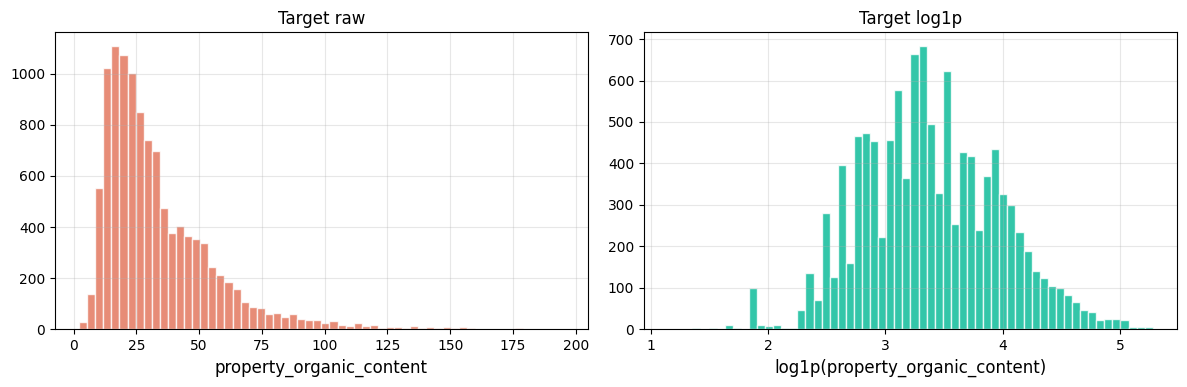

In [9]:
# log1p transform target — reduces skew 2.03 → near-normal
y_log = np.log1p(y_raw)
print(f'y (raw)   skew={pd.Series(y_raw).skew():.3f}')
print(f'y (log1p) skew={pd.Series(y_log).skew():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_raw, bins=60, color='#e17055', edgecolor='white', alpha=0.8)
axes[0].set_title('Target raw'); axes[0].set_xlabel('property_organic_content')
axes[1].hist(y_log, bins=60, color='#00b894', edgecolor='white', alpha=0.8)
axes[1].set_title('Target log1p'); axes[1].set_xlabel('log1p(property_organic_content)')
plt.tight_layout(); plt.savefig('outputs/04_target_logtransform.png'); plt.show()

## 5. Correlation Analysis

### 5.1 Spearman Correlation — Features vs Target

Since the normality tests confirmed the target is **non-normal** (SW p≪0.05, KS p≪0.05, skew≈2.0), we use **Spearman rank correlation** consistently for all feature–target and feature–feature analyses. Pearson is not appropriate here because it assumes normality and is sensitive to outliers (Hauke & Kossowski, 2011).

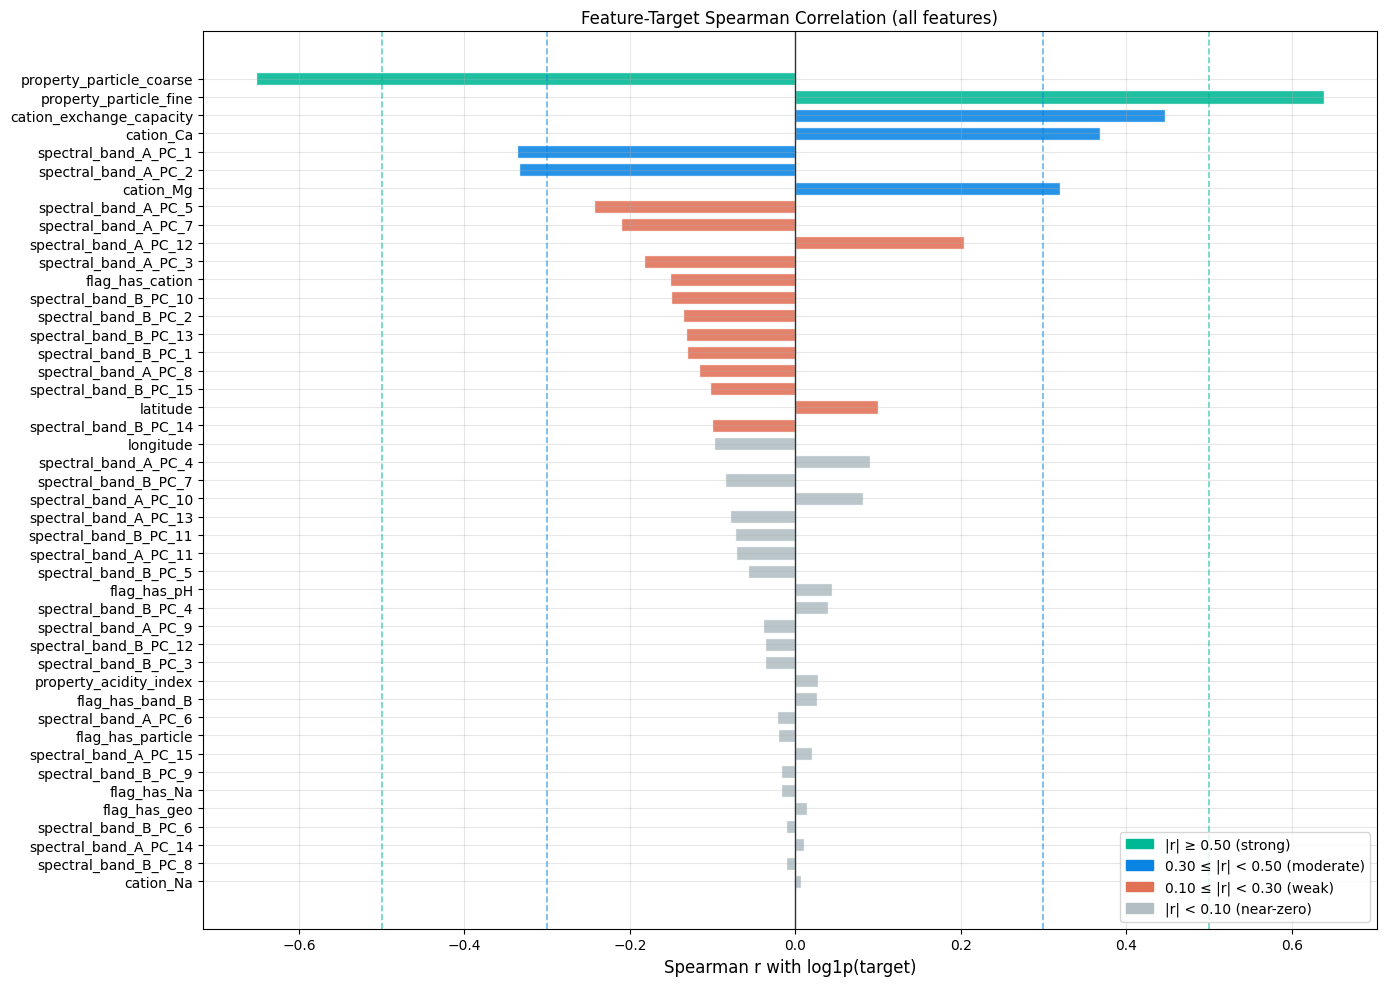

Top-10 by |Spearman r|:
                 feature  spearman_r  abs_spearman
property_particle_coarse     -0.6514        0.6514
  property_particle_fine      0.6386        0.6386
cation_exchange_capacity      0.4469        0.4469
               cation_Ca      0.3677        0.3677
    spectral_band_A_PC_1     -0.3367        0.3367
    spectral_band_A_PC_2     -0.3338        0.3338
               cation_Mg      0.3202        0.3202
    spectral_band_A_PC_5     -0.2430        0.2430
    spectral_band_A_PC_7     -0.2110        0.2110
   spectral_band_A_PC_12      0.2041        0.2041

Near-zero features (17): ['flag_has_pH', 'spectral_band_B_PC_4', 'spectral_band_A_PC_9', 'spectral_band_B_PC_12', 'spectral_band_B_PC_3', 'property_acidity_index', 'flag_has_band_B', 'spectral_band_A_PC_6', 'flag_has_particle', 'spectral_band_A_PC_15', 'spectral_band_B_PC_9', 'flag_has_Na', 'flag_has_geo', 'spectral_band_B_PC_6', 'spectral_band_A_PC_14', 'spectral_band_B_PC_8', 'cation_Na']


In [10]:
from scipy.stats import spearmanr, pearsonr

feat_names = X.select_dtypes(include=[np.number]).columns.tolist()
corr_rows  = []
for col in feat_names:
    series = X[col].values
    mask   = ~np.isnan(series)
    if mask.sum() < 30:
        continue
    rsp, psp = spearmanr(series[mask], y_log[mask])
    rpe, ppe = pearsonr(series[mask],  y_log[mask])
    corr_rows.append({
        'feature': col,
        'spearman_r': round(float(rsp), 4),
        'spearman_p': round(float(psp), 6),
        'pearson_r':  round(float(rpe), 4),
        'pearson_p':  round(float(ppe), 6),
        'abs_spearman': round(abs(rsp), 4),
        'near_zero': abs(rsp) < 0.05,
    })

corr_df = pd.DataFrame(corr_rows).sort_values('abs_spearman', ascending=False)
corr_df.to_csv('outputs/feature_target_correlation.csv', index=False)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
colors = []
for r in corr_df['abs_spearman']:
    if r >= 0.50: colors.append('#00b894')
    elif r >= 0.30: colors.append('#0984e3')
    elif r >= 0.10: colors.append('#e17055')
    else: colors.append('#b2bec3')

ax.barh(corr_df['feature'], corr_df['spearman_r'],
        color=colors, edgecolor='white', height=0.72, alpha=0.88)
ax.axvline(0,     color='#2d3436', lw=1.0)
ax.axvline(0.30,  color='#0984e3', lw=1.2, ls='--', alpha=0.6)
ax.axvline(-0.30, color='#0984e3', lw=1.2, ls='--', alpha=0.6)
ax.axvline(0.50,  color='#00b894', lw=1.2, ls='--', alpha=0.6)
ax.axvline(-0.50, color='#00b894', lw=1.2, ls='--', alpha=0.6)
p1 = mpatches.Patch(color='#00b894', label='|r| ≥ 0.50 (strong)')
p2 = mpatches.Patch(color='#0984e3', label='0.30 ≤ |r| < 0.50 (moderate)')
p3 = mpatches.Patch(color='#e17055', label='0.10 ≤ |r| < 0.30 (weak)')
p4 = mpatches.Patch(color='#b2bec3', label='|r| < 0.10 (near-zero)')
ax.legend(handles=[p1,p2,p3,p4], loc='lower right')
ax.set_xlabel('Spearman r with log1p(target)')
ax.set_title('Feature-Target Spearman Correlation (all features)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/05_spearman_bar.png')
plt.show()

top10 = corr_df.head(10)[['feature','spearman_r','abs_spearman']].reset_index(drop=True)
near_zero = corr_df[corr_df['near_zero']]['feature'].tolist()
print(f'Top-10 by |Spearman r|:')
print(top10.to_string(index=False))
print(f'\nNear-zero features ({len(near_zero)}): {near_zero}')

### 5.2 Intra-group Feature Redundancy

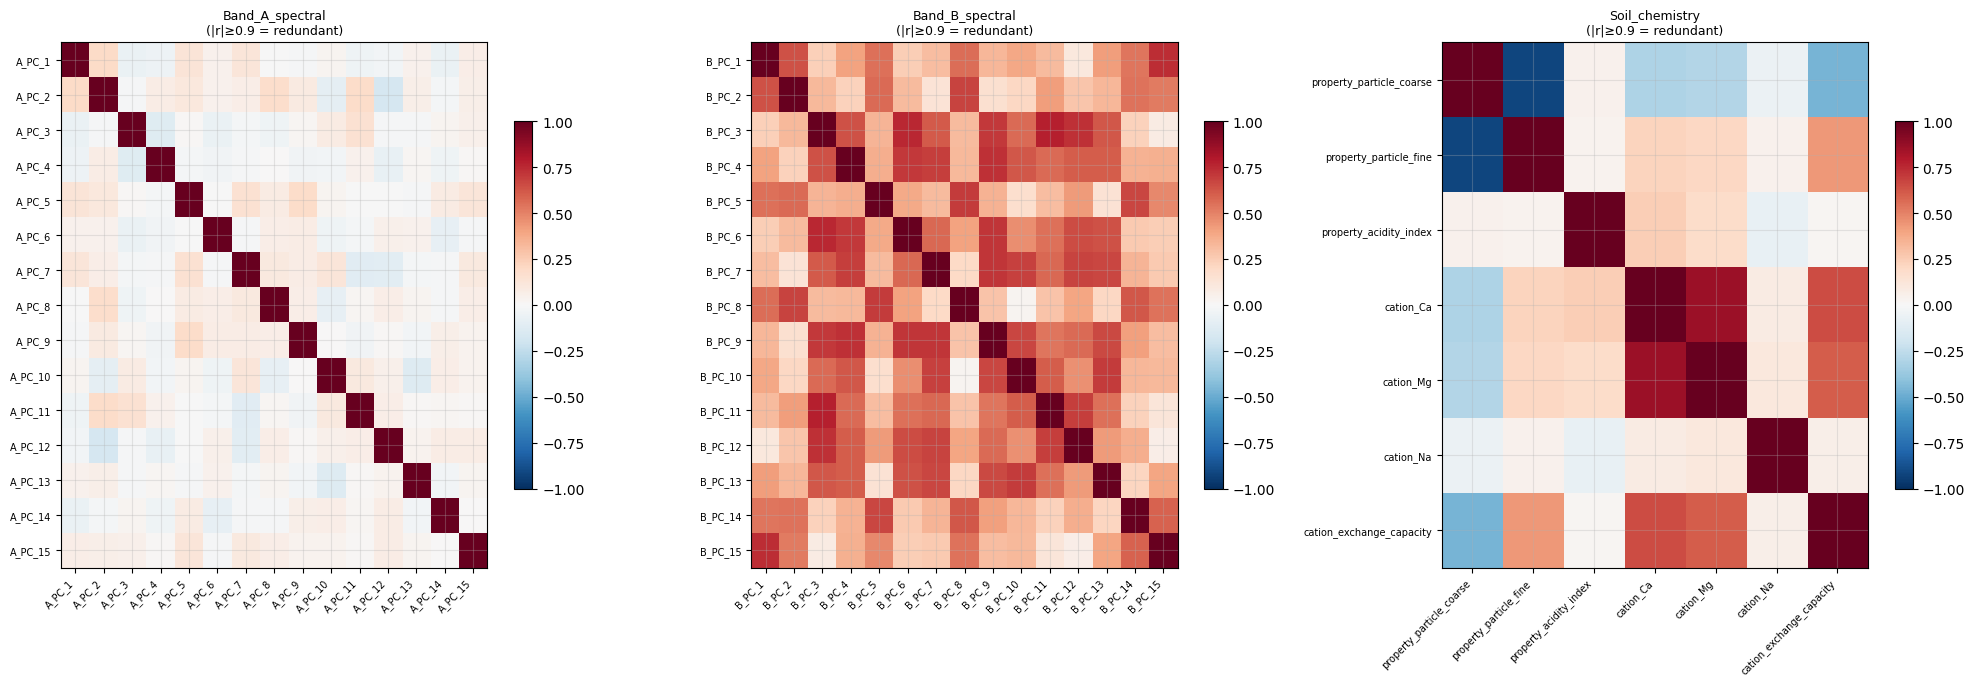

Redundant pairs (|r|≥0.9): 1
         group                   feat_a                 feat_b  spearman_r
Soil_chemistry property_particle_coarse property_particle_fine     -0.9147


In [11]:
# Check spectral band groups for redundancy
REDUND_THRESH = 0.90

groups = {
    'Band_A_spectral': [f'spectral_band_A_PC_{i}' for i in range(1, 16)],
    'Band_B_spectral': [f'spectral_band_B_PC_{i}' for i in range(1, 16)],
    'Soil_chemistry' : ['property_particle_coarse', 'property_particle_fine',
                        'property_acidity_index', 'cation_Ca', 'cation_Mg',
                        'cation_Na', 'cation_exchange_capacity'],
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
redundant_pairs = []

for ax, (grp_name, cols) in zip(axes, groups.items()):
    cols = [c for c in cols if c in X.columns]
    n    = len(cols)
    mat  = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            xi = X[cols[i]].values
            xj = X[cols[j]].values
            mask = ~(np.isnan(xi) | np.isnan(xj))
            if mask.sum() < 30:
                continue
            r, _ = spearmanr(xi[mask], xj[mask])
            mat[i,j] = mat[j,i] = float(r)
            if abs(r) >= REDUND_THRESH:
                redundant_pairs.append({'group': grp_name, 'feat_a': cols[i],
                                        'feat_b': cols[j], 'spearman_r': round(float(r),4)})
    short = [c.replace('spectral_band_A_', 'A_').replace('spectral_band_B_', 'B_') for c in cols]
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short, fontsize=7)
    ax.set_title(f'{grp_name}\n(|r|≥{REDUND_THRESH} = redundant)', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.savefig('outputs/06_redundancy_heatmap.png')
plt.show()

redund_df = pd.DataFrame(redundant_pairs)
print(f'Redundant pairs (|r|≥{REDUND_THRESH}): {len(redund_df)}')
if len(redund_df):
    print(redund_df.to_string(index=False))

## 6. Feature Engineering

### Biological / Scientific Background

The following engineered features are derived from domain knowledge in **soil science, geochemistry, and spectroscopy**:

1. **`depth_band_interaction`** — Sampling depth modulates organic matter decomposition rates (Jobbagy & Jackson, 2000). Encoded depth × spectral PC interaction.
2. **`spectral_ratio_A1_A2`** — Ratio of first two dominant PCs of optical spectrum captures reflectance contrast linked to humus content (Viscarra Rossel et al., 2006).
3. **`cation_Ca_Mg_ratio`** — Ca:Mg ratio is a proxy for base saturation and cation exchange dynamics that co-vary with organic carbon (Brady & Weil, 2008).
4. **`cation_total`** — Sum of Ca + Mg + Na approximates total soluble cation pool, influencing microbial decomposition of organic matter (Sollins et al., 1996).
5. **`CEC_per_clay`** — Cation Exchange Capacity normalized by fine particle fraction: a proxy for clay mineralogy and its sorption capacity for organic matter (Oades, 1988).
6. **`particle_ratio`** — Coarse/fine particle ratio = texture index; sandy soils have lower organic matter retention (Hassink, 1997).
7. **`particle_sum`** — Total particle measurement = proxy for data completeness / soil type classification.
8. **`band_A_energy`** — L2-norm of all Band A PCs = total spectral energy in the optical window (Shepherd & Walsh, 2002).
9. **`band_B_energy`** — L2-norm of all Band B PCs = MIR spectral energy; Band B is specifically sensitive to C-H, C=O bonds in organic matter (Soriano-Disla et al., 2014).
10. **`band_AB_contrast`** — |band_A_energy − band_B_energy|: spectral divergence between optical and MIR signals; useful when both are present.
11. **`geo_lat_lon_interaction`** — Latitude × Longitude encodes spatial autocorrelation of climate and vegetation patterns affecting organic matter turnover (Post et al., 1982).
12. **`lat_abs`** — Absolute latitude: proxy for distance from equator and associated temperature/precipitation gradients driving organic matter accumulation.

In [12]:
def engineer_features(df: pd.DataFrame, ref_df: pd.DataFrame = None) -> pd.DataFrame:
    df = df.copy()
    ref = ref_df if ref_df is not None else df
    
    spec_A_cols = [f'spectral_band_A_PC_{i}' for i in range(1, 16)]
    spec_B_cols = [f'spectral_band_B_PC_{i}' for i in range(1, 16)]
    
    # 1. Spectral energy (L2-norm across PCs)
    A_vals = df[spec_A_cols].values
    B_vals = df[spec_B_cols].values
    df['band_A_energy'] = np.sqrt(np.nansum(A_vals ** 2, axis=1))
    df['band_B_energy'] = np.sqrt(np.nansum(B_vals ** 2, axis=1))
    
    # 2. Spectral ratio: dominant PCs of Band A
    if 'spectral_band_A_PC_1' in df.columns and 'spectral_band_A_PC_2' in df.columns:
        pc1 = df['spectral_band_A_PC_1']
        pc2 = df['spectral_band_A_PC_2']
        df['spectral_ratio_A1_A2'] = pc1 / (np.abs(pc2) + 1e-8)
    
    # 3. Band AB contrast (only meaningful where both exist)
    df['band_AB_contrast'] = np.abs(df['band_A_energy'] - df['band_B_energy'])
    
    # 4. Ca:Mg ratio
    df['cation_Ca_Mg_ratio'] = df['cation_Ca'] / (df['cation_Mg'] + 1e-8)
    
    # 5. Total cation pool
    df['cation_total'] = df['cation_Ca'].fillna(0) + df['cation_Mg'].fillna(0) + df['cation_Na'].fillna(0)
    
    # 6. CEC per fine particle (clay proxy)
    df['CEC_per_clay'] = df['cation_exchange_capacity'] / (df['property_particle_fine'] + 1e-8)
    
    # 7. Particle texture ratio and sum
    df['particle_ratio'] = df['property_particle_coarse'] / (df['property_particle_fine'] + 1e-8)
    df['particle_sum']   = df['property_particle_coarse'].fillna(0) + df['property_particle_fine'].fillna(0)
    
    # 8. Geo interactions
    df['geo_lat_lon_interaction'] = df['latitude'] * df['longitude']
    df['lat_abs'] = np.abs(df['latitude'])
    
    # 9. Band A cumulative variance (PC1+PC2 vs rest) — captures spectral complexity
    if all(f'spectral_band_A_PC_{i}' in df.columns for i in range(1, 4)):
        df['band_A_PC1_PC2_share'] = (
            df['spectral_band_A_PC_1'].abs() + df['spectral_band_A_PC_2'].abs()
        ) / (df['band_A_energy'] + 1e-8)
    
    return df

X_eng  = engineer_features(X,      ref_df=X)
X_test_eng = engineer_features(X_test, ref_df=X)

new_feats = [c for c in X_eng.columns if c not in X.columns]
print(f'New engineered features ({len(new_feats)}): {new_feats}')
print(f'X_eng shape: {X_eng.shape}')

New engineered features (12): ['band_A_energy', 'band_B_energy', 'spectral_ratio_A1_A2', 'band_AB_contrast', 'cation_Ca_Mg_ratio', 'cation_total', 'CEC_per_clay', 'particle_ratio', 'particle_sum', 'geo_lat_lon_interaction', 'lat_abs', 'band_A_PC1_PC2_share']
X_eng shape: (11210, 65)


### 6.1 Engineering Gain vs Best Component

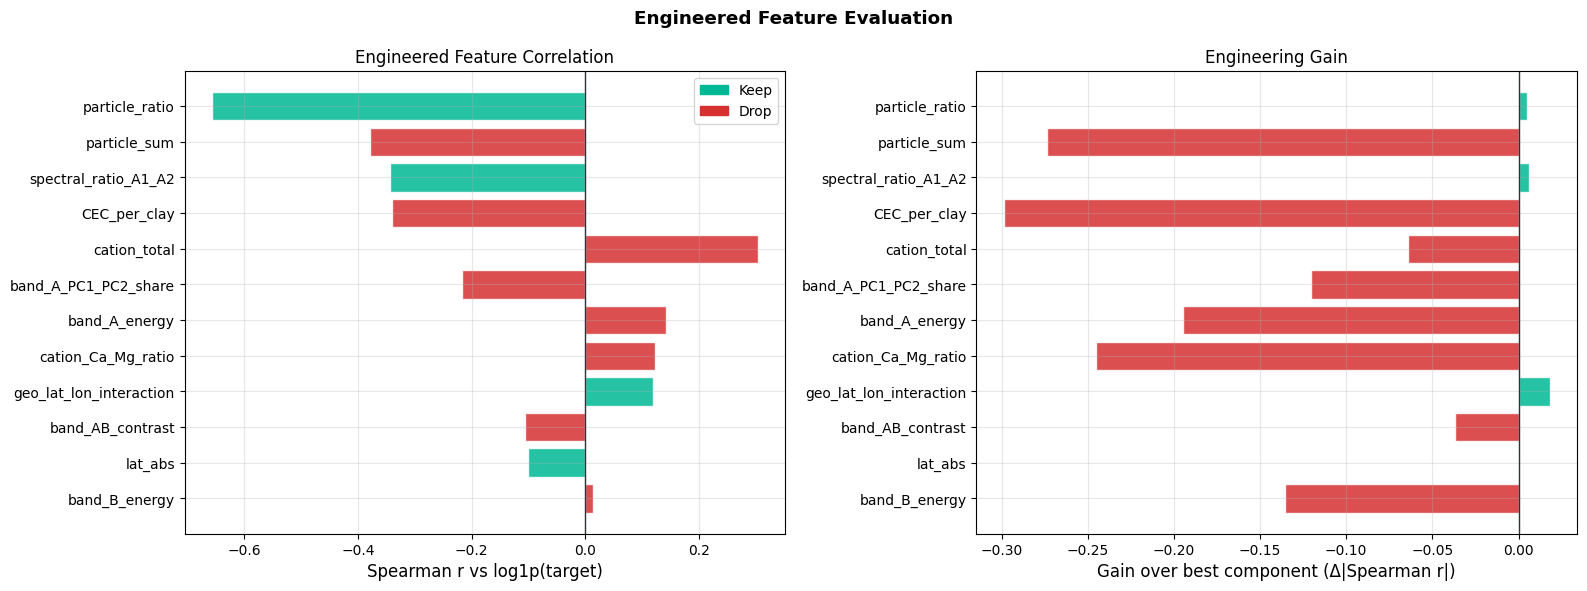

Keep (4): ['particle_ratio', 'spectral_ratio_A1_A2', 'geo_lat_lon_interaction', 'lat_abs']
Drop (8): ['particle_sum', 'CEC_per_clay', 'cation_total', 'band_A_PC1_PC2_share', 'band_A_energy', 'cation_Ca_Mg_ratio', 'band_AB_contrast', 'band_B_energy']

                feature  spearman_r  abs_r  best_component_r    gain  keep
         particle_ratio     -0.6565 0.6565           -0.6514  0.0051  True
           particle_sum     -0.3781 0.3781           -0.6514 -0.2734 False
   spectral_ratio_A1_A2     -0.3428 0.3428           -0.3367  0.0060  True
           CEC_per_clay     -0.3399 0.3399            0.6386 -0.2987 False
           cation_total      0.3038 0.3038            0.3677 -0.0639 False
   band_A_PC1_PC2_share     -0.2163 0.2163           -0.3367 -0.1204 False
          band_A_energy      0.1419 0.1419           -0.3367 -0.1948 False
     cation_Ca_Mg_ratio      0.1228 0.1228            0.3677 -0.2450 False
geo_lat_lon_interaction      0.1185 0.1185            0.1004  0.0181  True

In [13]:
# Evaluate each engineered feature's Spearman r vs its best component
eng_eval_rows = []

component_map = {
    'band_A_energy':          [f'spectral_band_A_PC_{i}' for i in range(1, 16)],
    'band_B_energy':          [f'spectral_band_B_PC_{i}' for i in range(1, 16)],
    'spectral_ratio_A1_A2':   ['spectral_band_A_PC_1', 'spectral_band_A_PC_2'],
    'band_AB_contrast':       ['band_A_energy', 'band_B_energy'],
    'cation_Ca_Mg_ratio':     ['cation_Ca', 'cation_Mg'],
    'cation_total':           ['cation_Ca', 'cation_Mg', 'cation_Na'],
    'CEC_per_clay':           ['cation_exchange_capacity', 'property_particle_fine'],
    'particle_ratio':         ['property_particle_coarse', 'property_particle_fine'],
    'particle_sum':           ['property_particle_coarse', 'property_particle_fine'],
    'geo_lat_lon_interaction':['latitude', 'longitude'],
    'lat_abs':                ['latitude'],
    'band_A_PC1_PC2_share':   ['spectral_band_A_PC_1', 'spectral_band_A_PC_2'],
}

def _sr(a, b):
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 30: return 0.0
    r, _ = spearmanr(a[mask], b[mask])
    return float(r)

for feat in new_feats:
    if feat not in X_eng.columns: continue
    feat_r = _sr(X_eng[feat].values, y_log)
    comps  = component_map.get(feat, [])
    comp_rs= [_sr(X_eng[c].values if c in X_eng.columns else X[c].values if c in X.columns else np.full(len(y_log), np.nan), y_log) for c in comps]
    best_r = max(comp_rs, key=abs) if comp_rs else 0.0
    gain   = abs(feat_r) - abs(best_r)
    eng_eval_rows.append({
        'feature':          feat,
        'spearman_r':       round(feat_r, 4),
        'abs_r':            round(abs(feat_r), 4),
        'best_component_r': round(best_r, 4),
        'gain':             round(gain, 4),
        'keep':             abs(feat_r) >= abs(best_r) - 0.01,  # keep if not significantly worse
    })

eng_eval_df = pd.DataFrame(eng_eval_rows).sort_values('abs_r', ascending=False)
eng_eval_df.to_csv('outputs/engineered_feature_eval.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Engineered Feature Evaluation', fontweight='bold')

ax = axes[0]
bar_colors = ['#00b894' if r else '#d63031' for r in eng_eval_df['keep']]
ax.barh(eng_eval_df['feature'], eng_eval_df['spearman_r'],
        color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='#2d3436', lw=1)
ax.set_xlabel('Spearman r vs log1p(target)')
ax.set_title('Engineered Feature Correlation')
ax.invert_yaxis()
p1 = mpatches.Patch(color='#00b894', label='Keep'); p2 = mpatches.Patch(color='#d63031', label='Drop')
ax.legend(handles=[p1,p2])

ax = axes[1]
gain_colors = ['#00b894' if g >= 0 else '#d63031' for g in eng_eval_df['gain']]
ax.barh(eng_eval_df['feature'], eng_eval_df['gain'],
        color=gain_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='#2d3436', lw=1)
ax.set_xlabel('Gain over best component (Δ|Spearman r|)')
ax.set_title('Engineering Gain')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/07_engineering_gain.png')
plt.show()

kept_eng   = eng_eval_df[eng_eval_df['keep']]['feature'].tolist()
dropped_eng= eng_eval_df[~eng_eval_df['keep']]['feature'].tolist()
print(f'Keep ({len(kept_eng)}): {kept_eng}')
print(f'Drop ({len(dropped_eng)}): {dropped_eng}')
print()
print(eng_eval_df.to_string(index=False))

In [14]:
# Drop features that perform strictly worse than their components
if dropped_eng:
    X_eng      = X_eng.drop(columns=[c for c in dropped_eng if c in X_eng.columns])
    X_test_eng = X_test_eng.drop(columns=[c for c in dropped_eng if c in X_test_eng.columns])

print(f'Final feature matrix: {X_eng.shape}')
print(f'Features:', X_eng.columns.tolist())

Final feature matrix: (11210, 57)
Features: ['source_id', 'sampling_strategy', 'geo_zone_macro', 'geo_zone_micro', 'geo_zone_meso', 'land_cover_type', 'biome', 'parent_rock_type', 'property_particle_coarse', 'property_particle_fine', 'property_acidity_index', 'cation_Ca', 'cation_Mg', 'cation_Na', 'cation_exchange_capacity', 'latitude', 'longitude', 'spectral_band_A_PC_1', 'spectral_band_A_PC_2', 'spectral_band_A_PC_3', 'spectral_band_A_PC_4', 'spectral_band_A_PC_5', 'spectral_band_A_PC_6', 'spectral_band_A_PC_7', 'spectral_band_A_PC_8', 'spectral_band_A_PC_9', 'spectral_band_A_PC_10', 'spectral_band_A_PC_11', 'spectral_band_A_PC_12', 'spectral_band_A_PC_13', 'spectral_band_A_PC_14', 'spectral_band_A_PC_15', 'spectral_band_B_PC_1', 'spectral_band_B_PC_2', 'spectral_band_B_PC_3', 'spectral_band_B_PC_4', 'spectral_band_B_PC_5', 'spectral_band_B_PC_6', 'spectral_band_B_PC_7', 'spectral_band_B_PC_8', 'spectral_band_B_PC_9', 'spectral_band_B_PC_10', 'spectral_band_B_PC_11', 'spectral_band_B

## 7. Model Selection

### Why LightGBM?

Based on EDA results:
- **Massively missing data** (Band B: 85%, lat/lon: 79%): LightGBM handles NaN natively via optimal split assignment — no imputation required for the model itself (Chen & Guestrin, 2016; Ke et al., 2017).
- **Mixed feature types**: categorical (encoded), continuous, and binary flags — LightGBM handles all efficiently.
- **Highly skewed target** (skew≈2.0): LightGBM with `objective='regression_l1'` (MAE-based) is more robust to outliers than MSE; we also use `huber` loss as an alternative.
- **Non-linear relationships likely**: Spearman dominates Pearson across most features, indicating monotone but non-linear associations.
- **Tabular data with heterogeneous sources**: gradient boosting consistently outperforms linear models and NNs on structured tabular competitions (Shwartz-Ziv & Armon, 2022).
- **Computational efficiency**: LightGBM's leaf-wise growth strategy makes it faster than XGBoost on this dataset size.

### SHAP Feature Selection — Cumulative 95% Threshold

We use the **cumulative SHAP importance** threshold (≥95% of total |SHAP| mass) as the feature pruning criterion. This approach is grounded in:
- Lundberg & Lee (2017): SHAP values provide theoretically consistent, locally accurate feature attributions based on Shapley values from cooperative game theory.
- Molnar (2020, *Interpretable Machine Learning*): cumulative importance selects features that collectively explain the vast majority of model variance without an arbitrary absolute cutoff.
- Unlike a static threshold (e.g., mean|SHAP| ≥ 0.001), cumulative % is robust to scale changes across different model runs.

### 7.1 Baseline LightGBM — 5-Fold CV

In [15]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
feat_names_eng = X_eng.columns.tolist()

# Baseline params (conservative)
BASELINE_PARAMS = {
    'boosting_type':    'gbdt',
    'objective':        'regression_l1',
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      SEED,
    'verbose':          -1,
    'n_jobs':           -1,
}

oof_preds = np.zeros(len(X_eng))
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_eng)):
    X_tr, X_val = X_eng.iloc[tr_idx], X_eng.iloc[val_idx]
    y_tr, y_val = y_log[tr_idx], y_log[val_idx]
    
    model = lgb.LGBMRegressor(**BASELINE_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    
    pred_val_log = model.predict(X_val)
    oof_preds[val_idx] = pred_val_log
    
    # RMSE in original scale
    pred_val = np.expm1(pred_val_log)
    y_val_orig = np.expm1(y_val)
    rmse_fold = np.sqrt(mean_squared_error(y_val_orig, pred_val))
    cv_scores.append(rmse_fold)
    print(f'Fold {fold+1}: RMSE={rmse_fold:.4f}  best_iter={model.best_iteration_}')

oof_orig = np.expm1(oof_preds)
y_orig   = np.expm1(y_log)
oof_rmse = np.sqrt(mean_squared_error(y_orig, oof_orig))
print(f'\nOOF RMSE (original scale): {oof_rmse:.4f}')
print(f'CV mean ± std: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

Fold 1: RMSE=11.3926  best_iter=603
Fold 2: RMSE=11.1844  best_iter=999
Fold 3: RMSE=11.5715  best_iter=1000
Fold 4: RMSE=12.1076  best_iter=1000
Fold 5: RMSE=12.8062  best_iter=990

OOF RMSE (original scale): 11.8269
CV mean ± std: 11.8124 ± 0.5837


### 7.2 SHAP Feature Pruning (Cumulative 95%)

SHAP cumulative 95% threshold: keep 32/57 features
Kept: ['particle_ratio', 'cation_exchange_capacity', 'source_id', 'property_particle_coarse', 'property_particle_fine', 'geo_zone_meso', 'spectral_band_A_PC_5', 'spectral_band_A_PC_3', 'spectral_band_A_PC_15', 'spectral_band_A_PC_7', 'spectral_band_A_PC_2', 'spectral_band_A_PC_10', 'spectral_band_A_PC_6', 'cation_Ca', 'spectral_band_A_PC_9', 'spectral_ratio_A1_A2', 'land_cover_type', 'cation_Mg', 'spectral_band_A_PC_8', 'spectral_band_A_PC_4', 'geo_zone_micro', 'spectral_band_A_PC_13', 'spectral_band_B_PC_9', 'spectral_band_A_PC_1', 'spectral_band_A_PC_12', 'spectral_band_A_PC_14', 'spectral_band_B_PC_10', 'spectral_band_A_PC_11', 'spectral_band_B_PC_4', 'property_acidity_index', 'biome', 'sampling_strategy']
Dropped: ['spectral_band_B_PC_7', 'spectral_band_B_PC_3', 'spectral_band_B_PC_1', 'spectral_band_B_PC_15', 'spectral_band_B_PC_14', 'flag_has_pH', 'geo_lat_lon_interaction', 'spectral_band_B_PC_11', 'spectral_band_B_PC_12', 'latit

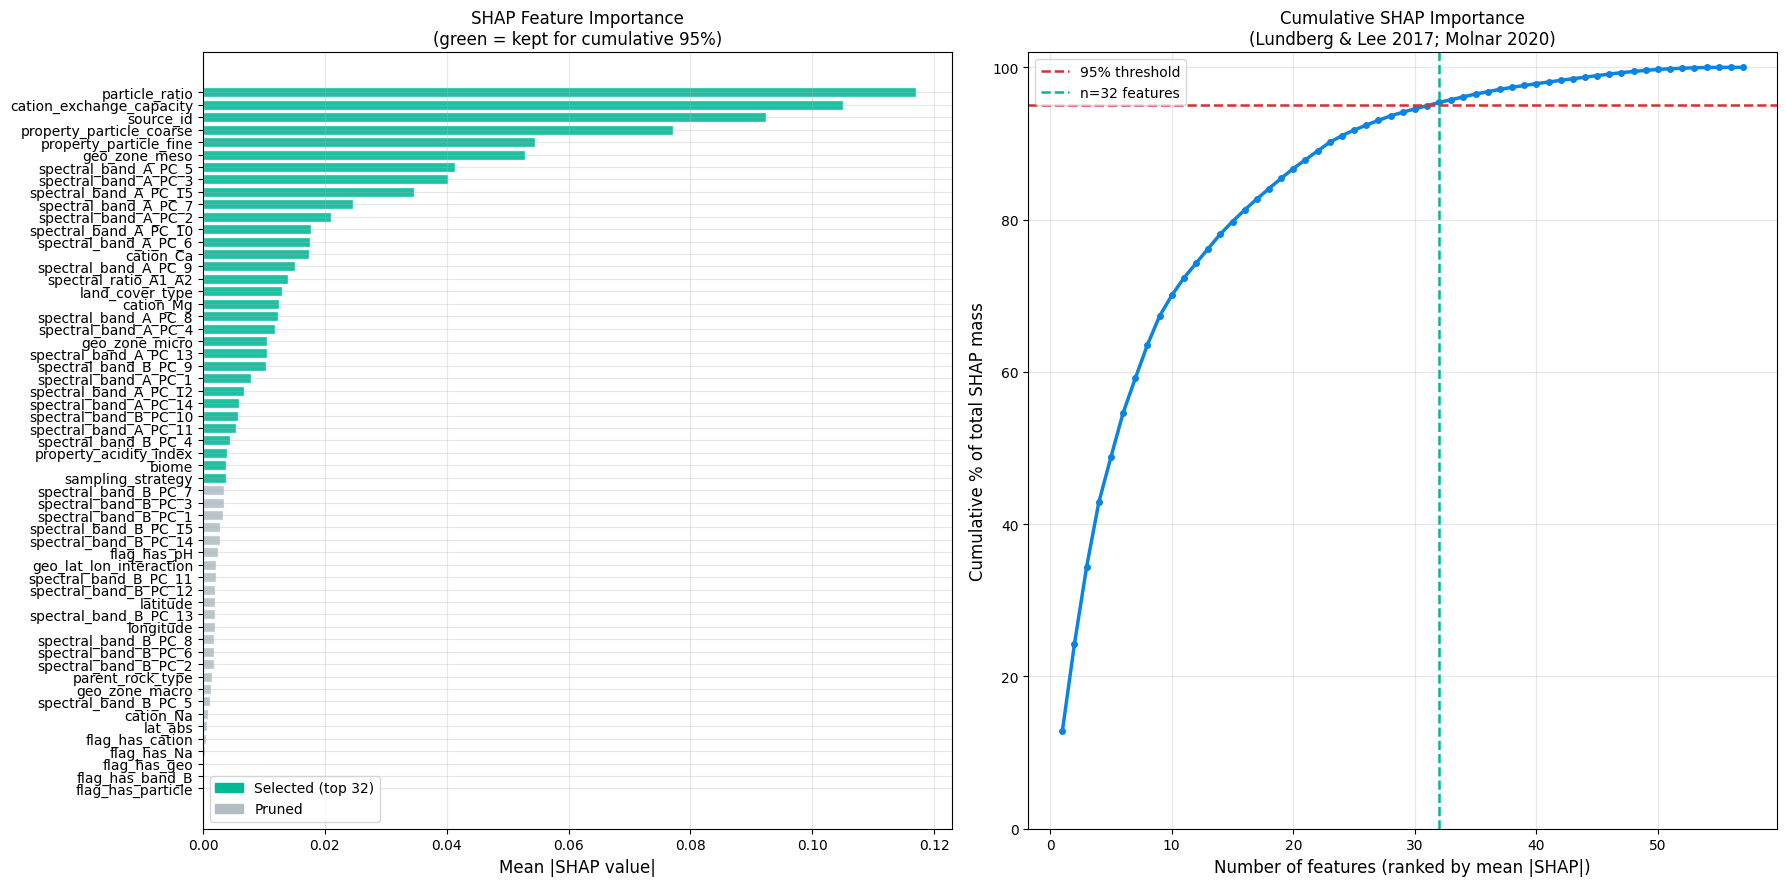


Generating SHAP beeswarm plot...


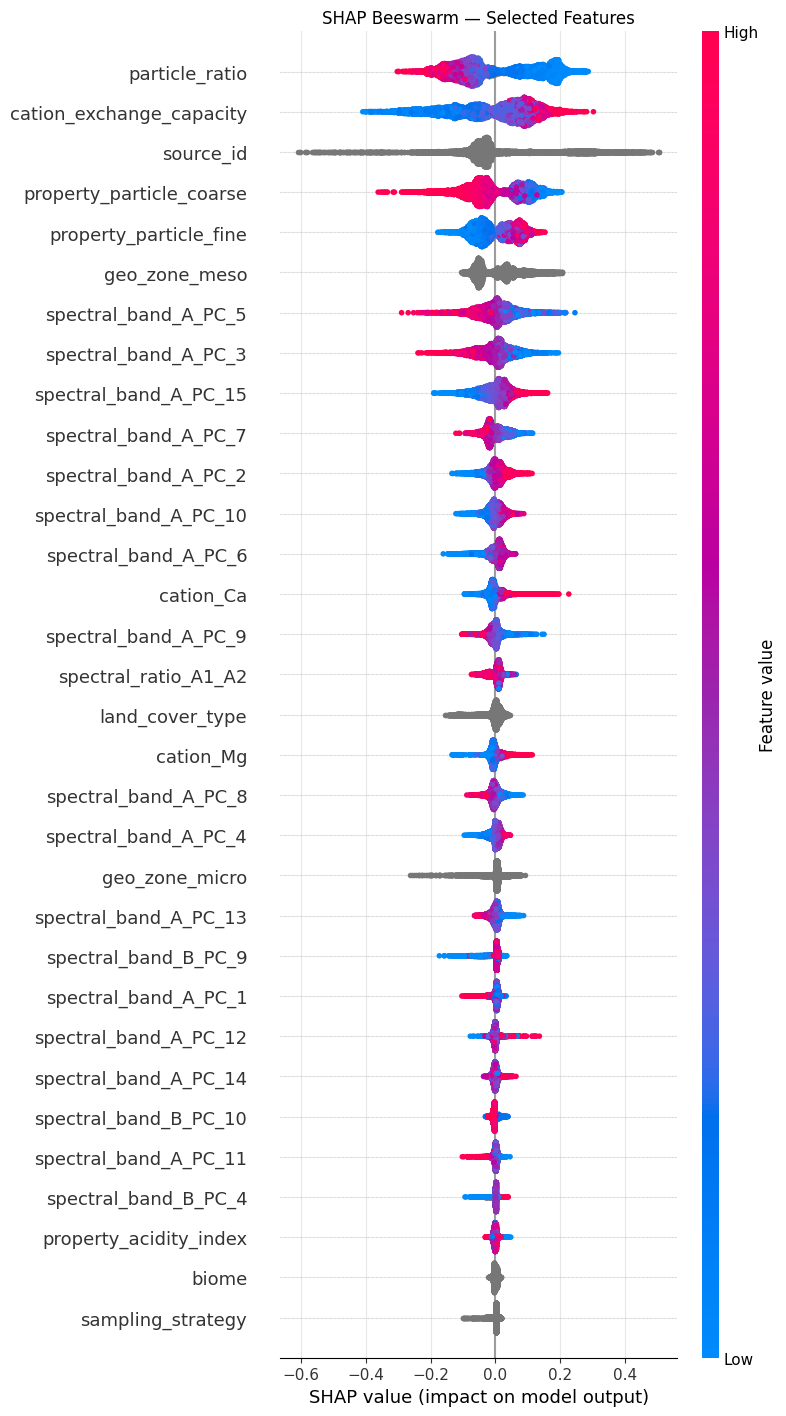

In [16]:
# Train a single model on full data for SHAP analysis
baseline_full = lgb.LGBMRegressor(**BASELINE_PARAMS)
baseline_full.fit(X_eng, y_log, callbacks=[lgb.log_evaluation(-1)])

# SHAP values
explainer  = shap.TreeExplainer(baseline_full)
shap_vals  = explainer.shap_values(X_eng)

if isinstance(shap_vals, list):  # multi-output fallback
    shap_vals = shap_vals[0]

mean_shap  = np.abs(shap_vals).mean(axis=0)
total_shap = mean_shap.sum()

order = np.argsort(mean_shap)[::-1]
cumulative_pct = np.cumsum(mean_shap[order]) / total_shap

SHAP_THRESHOLD = 0.95
n_keep = int(np.searchsorted(cumulative_pct, SHAP_THRESHOLD)) + 1

selected_feats  = [feat_names_eng[i] for i in order[:n_keep]]
dropped_feats   = [feat_names_eng[i] for i in order[n_keep:]]

print(f'SHAP cumulative 95% threshold: keep {n_keep}/{len(feat_names_eng)} features')
print(f'Kept: {selected_feats}')
print(f'Dropped: {dropped_feats}')

# ── SHAP summary bar plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax = axes[0]
shap_table = sorted(zip(feat_names_eng, mean_shap), key=lambda x: -x[1])
feat_labels, shap_vals_plot = zip(*shap_table)
bar_colors = ['#00b894' if f in selected_feats else '#b2bec3' for f in feat_labels]
ax.barh(feat_labels, shap_vals_plot, color=bar_colors, edgecolor='white', alpha=0.88)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'SHAP Feature Importance\n(green = kept for cumulative 95%)')
ax.invert_yaxis()
p1 = mpatches.Patch(color='#00b894', label=f'Selected (top {n_keep})')
p2 = mpatches.Patch(color='#b2bec3', label='Pruned')
ax.legend(handles=[p1, p2])

ax = axes[1]
cumulative_ordered = np.cumsum(mean_shap[order]) / total_shap
ax.plot(range(1, len(feat_names_eng)+1), cumulative_ordered * 100,
        color='#0984e3', lw=2.5, marker='o', markersize=4)
ax.axhline(95, color='#d63031', ls='--', lw=1.8, label='95% threshold')
ax.axvline(n_keep, color='#00b894', ls='--', lw=1.8, label=f'n={n_keep} features')
ax.set_xlabel('Number of features (ranked by mean |SHAP|)')
ax.set_ylabel('Cumulative % of total SHAP mass')
ax.set_title('Cumulative SHAP Importance\n(Lundberg & Lee 2017; Molnar 2020)')
ax.legend(); ax.set_ylim(0, 102)

plt.tight_layout()
plt.savefig('outputs/08_shap_importance.png')
plt.show()

# SHAP beeswarm for selected features
print('\nGenerating SHAP beeswarm plot...')
fig_shap, ax_shap = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_vals[:, order[:n_keep]],
                  X_eng.iloc[:, order[:n_keep]],
                  show=False, max_display=n_keep)
plt.title('SHAP Beeswarm — Selected Features')
plt.tight_layout()
plt.savefig('outputs/09_shap_beeswarm.png')
plt.show()

In [17]:
X_sel      = X_eng[selected_feats]
X_test_sel = X_test_eng[selected_feats]

print(f'Selected features ({len(selected_feats)}): {selected_feats}')
print(f'X_sel: {X_sel.shape}  |  X_test_sel: {X_test_sel.shape}')

Selected features (32): ['particle_ratio', 'cation_exchange_capacity', 'source_id', 'property_particle_coarse', 'property_particle_fine', 'geo_zone_meso', 'spectral_band_A_PC_5', 'spectral_band_A_PC_3', 'spectral_band_A_PC_15', 'spectral_band_A_PC_7', 'spectral_band_A_PC_2', 'spectral_band_A_PC_10', 'spectral_band_A_PC_6', 'cation_Ca', 'spectral_band_A_PC_9', 'spectral_ratio_A1_A2', 'land_cover_type', 'cation_Mg', 'spectral_band_A_PC_8', 'spectral_band_A_PC_4', 'geo_zone_micro', 'spectral_band_A_PC_13', 'spectral_band_B_PC_9', 'spectral_band_A_PC_1', 'spectral_band_A_PC_12', 'spectral_band_A_PC_14', 'spectral_band_B_PC_10', 'spectral_band_A_PC_11', 'spectral_band_B_PC_4', 'property_acidity_index', 'biome', 'sampling_strategy']
X_sel: (11210, 32)  |  X_test_sel: (2670, 32)


## 8. Hyperparameter Tuning — Optuna Bayesian Search

In [18]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

N_TRIALS = 60  # Safe to increase to 150+ once pruning is active!
kf_tune  = KFold(n_splits=5, shuffle=True, random_state=SEED)

def objective(trial: optuna.Trial) -> float:
    params = {
        'boosting_type':      'gbdt',
        'objective':          trial.suggest_categorical('objective', ['regression', 'rmse']),
        'n_estimators':       trial.suggest_int('n_estimators', 500, 3000, step=100),
        'learning_rate':      trial.suggest_float('learning_rate', 0.003, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 60),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain':     trial.suggest_float('min_split_gain', 0.0, 0.5),
        'random_state':       SEED,
        'verbose':            -1,
        'n_jobs':             -1,
    }
    
    fold_scores = []
    
    # Added enumerate to track the fold index for pruning
    for fold_idx, (tr_idx, val_idx) in enumerate(kf_tune.split(X_sel)):
        X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
        y_tr, y_val = y_log[tr_idx], y_log[val_idx]
        
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
        
        pred = np.expm1(m.predict(X_val))
        rmse = np.sqrt(mean_squared_error(np.expm1(y_val), pred))
        fold_scores.append(rmse)
        
        # --- OPTUNA PRUNING LOGIC ---
        # Report the current rolling average RMSE to Optuna after this fold
        current_avg = np.mean(fold_scores)
        trial.report(current_avg, step=fold_idx)
        
        # Check if this trial is performing significantly worse than previous trials
        if trial.should_prune():
            raise optuna.TrialPruned()
        # ----------------------------

    return float(np.mean(fold_scores))

print(f'Starting Optuna search ({N_TRIALS} trials with MedianPruner)...')

# Added MedianPruner to automatically terminate unpromising trials
study = optuna.create_study(
    direction='minimize', 
    sampler=TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1) # Warmup allows fold 0 to always finish
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV RMSE: {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Starting Optuna search (60 trials with MedianPruner)...


Best trial: 31. Best value: 11.6581: 100%|██████████| 60/60 [05:19<00:00,  5.33s/it]


Best CV RMSE: 11.6581
Best params:
  objective: regression
  n_estimators: 2300
  learning_rate: 0.02275055869441503
  num_leaves: 127
  min_child_samples: 57
  subsample: 0.8150098669716366
  colsample_bytree: 0.8205115457429849
  reg_alpha: 0.00012866415558500767
  reg_lambda: 0.2230612518945584
  min_split_gain: 0.009702549019134712


## 9. Final Model Training — 5-Fold + Full Fit

In [19]:
BEST_PARAMS = {
    **study.best_params,
    'random_state': SEED,
    'verbose':     -1,
    'n_jobs':      -1,
}

kf_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_final = np.zeros(len(X_sel))
test_preds_folds = np.zeros((len(X_test_sel), 5))
cv_rmse_final = []

for fold, (tr_idx, val_idx) in enumerate(kf_final.split(X_sel)):
    X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
    y_tr, y_val = y_log[tr_idx],       y_log[val_idx]
    
    m = lgb.LGBMRegressor(**BEST_PARAMS)
    m.fit(X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(-1)])
    
    pred_log = m.predict(X_val)
    oof_final[val_idx] = pred_log
    pred_orig = np.expm1(pred_log)
    y_val_orig = np.expm1(y_val)
    rmse_f = np.sqrt(mean_squared_error(y_val_orig, pred_orig))
    cv_rmse_final.append(rmse_f)
    
    test_preds_folds[:, fold] = np.expm1(m.predict(X_test_sel))
    print(f'Fold {fold+1}: RMSE={rmse_f:.4f}  best_iter={m.best_iteration_}')

oof_orig_final = np.expm1(oof_final)
y_orig_final   = np.expm1(y_log)
oof_rmse_final = np.sqrt(mean_squared_error(y_orig_final, oof_orig_final))

# Average test predictions across folds
test_preds_avg = test_preds_folds.mean(axis=1)

print(f'\nFinal OOF RMSE: {oof_rmse_final:.4f}')
print(f'CV mean ± std : {np.mean(cv_rmse_final):.4f} ± {np.std(cv_rmse_final):.4f}')
print(f'Improvement over baseline: {oof_rmse - oof_rmse_final:+.4f}')

Fold 1: RMSE=10.9004  best_iter=561
Fold 2: RMSE=11.0479  best_iter=799
Fold 3: RMSE=11.4399  best_iter=535
Fold 4: RMSE=12.2233  best_iter=504
Fold 5: RMSE=12.7128  best_iter=529

Final OOF RMSE: 11.6856
CV mean ± std : 11.6649 ± 0.6965
Improvement over baseline: +0.1412


## 10. Evaluation Plots

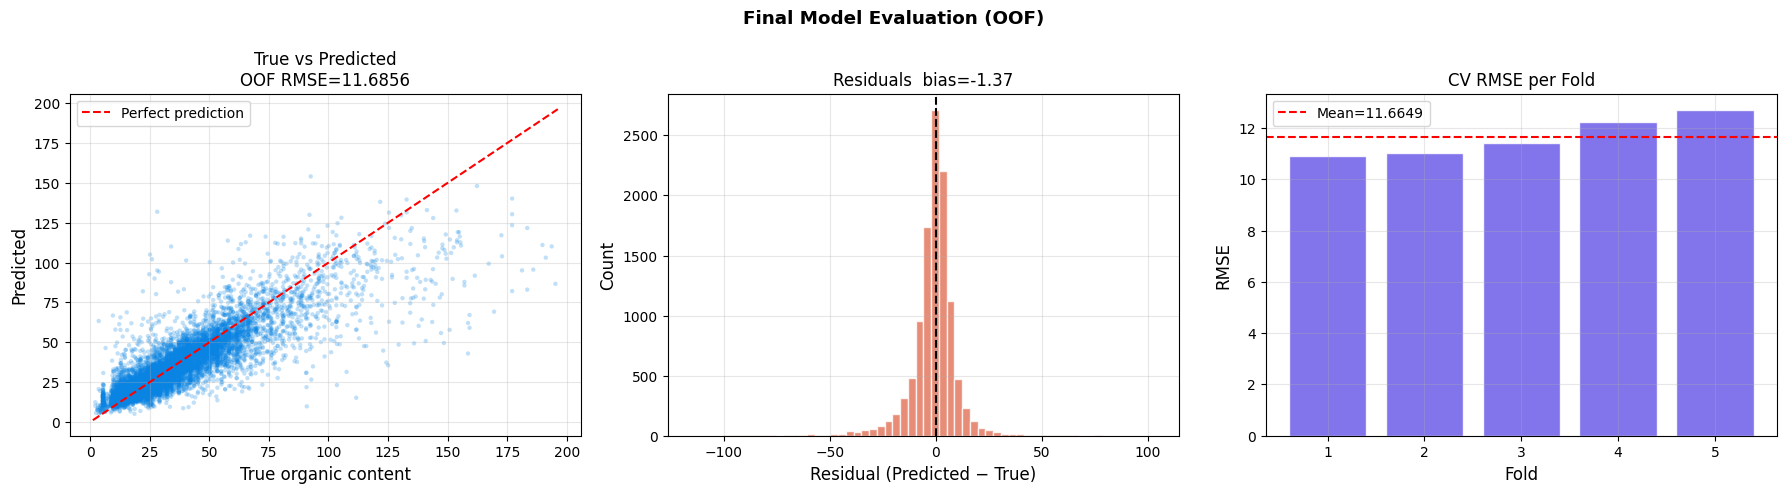

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Final Model Evaluation (OOF)', fontweight='bold')

# Scatter: true vs predicted
ax = axes[0]
ax.scatter(y_orig_final, oof_orig_final, alpha=0.25, s=10, color='#0984e3', edgecolors='none')
lims = [min(y_orig_final.min(), oof_orig_final.min())-1,
        max(y_orig_final.max(), oof_orig_final.max())+1]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('True organic content'); ax.set_ylabel('Predicted')
ax.set_title(f'True vs Predicted\nOOF RMSE={oof_rmse_final:.4f}')
ax.legend()

# Residuals histogram
ax = axes[1]
residuals = oof_orig_final - y_orig_final
ax.hist(residuals, bins=60, color='#e17055', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Residual (Predicted − True)'); ax.set_ylabel('Count')
ax.set_title(f'Residuals  bias={residuals.mean():+.2f}')

# CV RMSE per fold
ax = axes[2]
ax.bar(range(1, 6), cv_rmse_final, color='#6c5ce7', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(cv_rmse_final), color='red', ls='--', lw=1.5, label=f'Mean={np.mean(cv_rmse_final):.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE')
ax.set_title('CV RMSE per Fold'); ax.legend()

plt.tight_layout()
plt.savefig('outputs/10_evaluation.png')
plt.show()

Calculating SHAP values for 11210 rows in 12 batches...


SHAP Calculation: 100%|██████████| 12/12 [01:36<00:00,  8.02s/it]


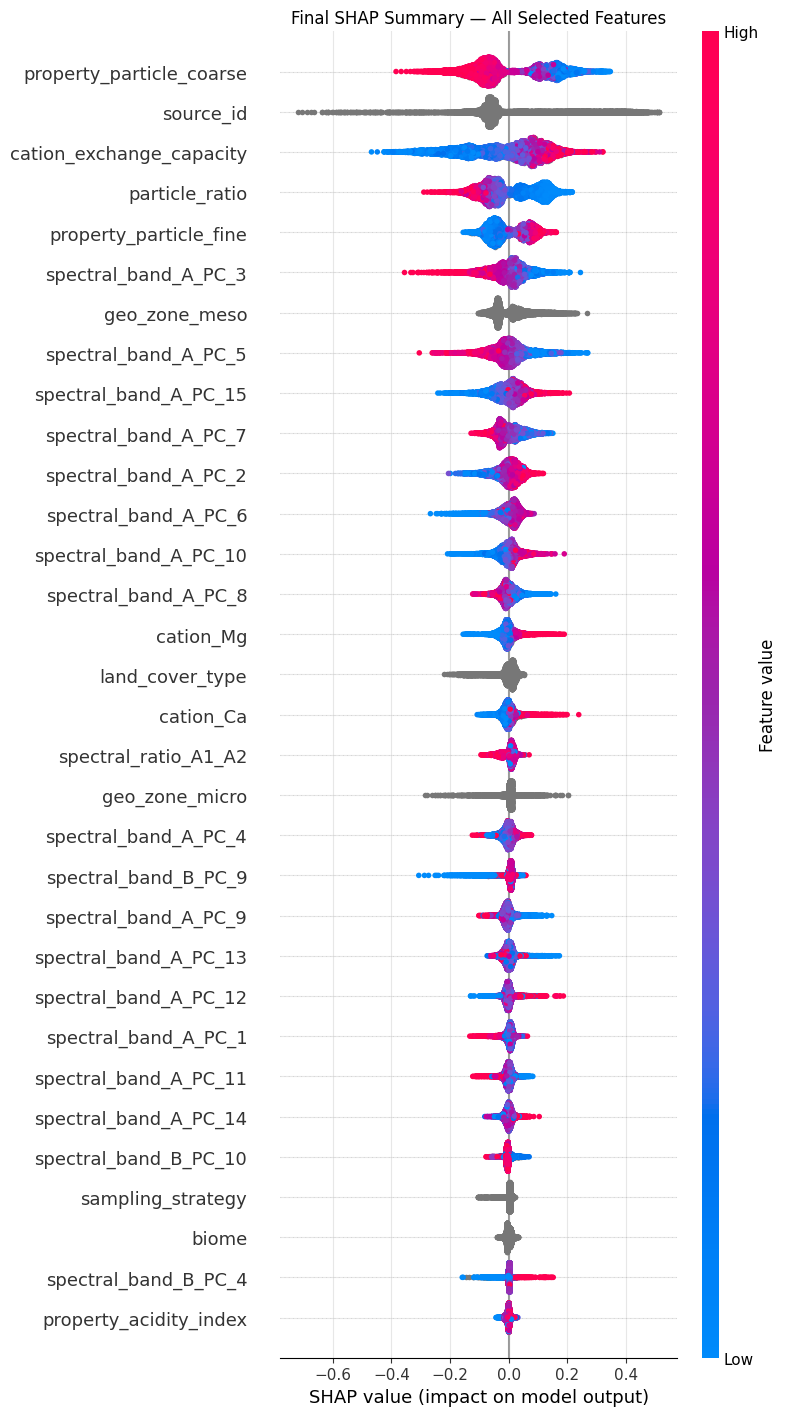

In [21]:
import numpy as np
from tqdm.auto import tqdm
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

# Refit on full data with best params for final SHAP
final_model = lgb.LGBMRegressor(**BEST_PARAMS)
final_model.fit(X_sel, y_log, callbacks=[lgb.log_evaluation(-1)])

exp_final = shap.TreeExplainer(final_model)

# ==========================================
# NEW BATCHED SHAP CALCULATION WITH PROGRESS BAR
# ==========================================
batch_size = 1000
n_batches = int(np.ceil(len(X_sel) / batch_size))

print(f"Calculating SHAP values for {len(X_sel)} rows in {n_batches} batches...")

sv_final_list = []

# Loop through batches with a progress bar
for i in tqdm(range(n_batches), desc="SHAP Calculation"):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(X_sel))
    
    # Slice the batch
    X_batch = X_sel.iloc[start_idx:end_idx]
    
    # Calculate and append
    batch_shap = exp_final.shap_values(X_batch, check_additivity=False)
    sv_final_list.append(batch_shap)

# Combine the batches back into a single array
sv_final = np.vstack(sv_final_list)
# ==========================================

# Your original plotting code
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(sv_final, X_sel, show=False, max_display=len(selected_feats))
plt.title('Final SHAP Summary — All Selected Features')
plt.tight_layout()
plt.savefig('outputs/11_shap_final.png')
plt.show()

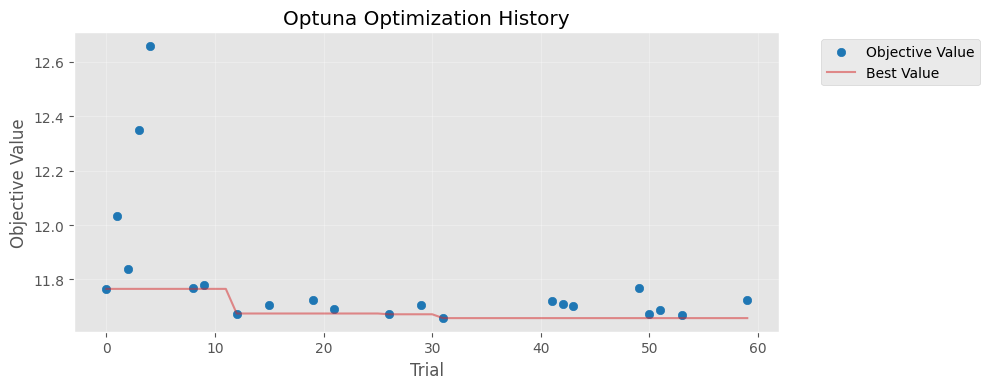

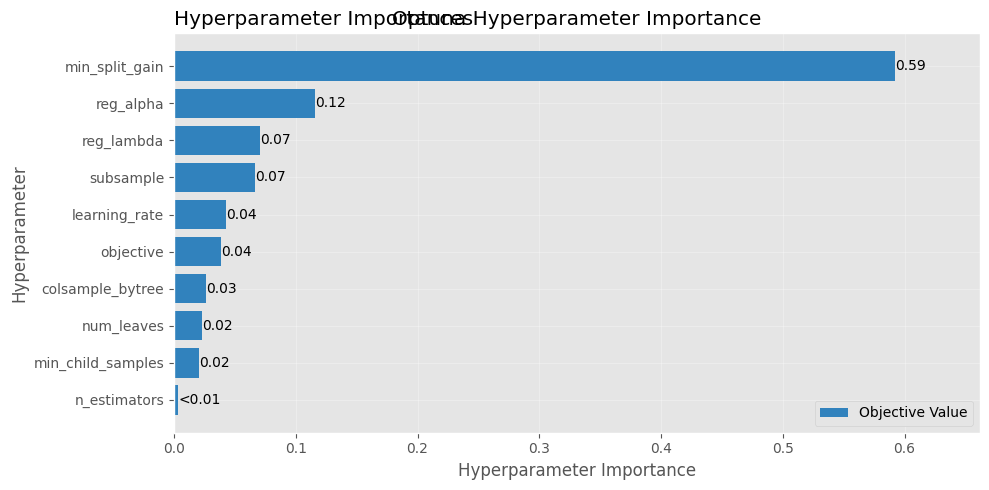

In [22]:
try:
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
    import matplotlib.pyplot as plt

    # 1. Plot Optimization History
    ax1 = plot_optimization_history(study)  # Capture the returned Axes object
    ax1.set_title('Optuna Optimization History')
    
    # Adjust size using the figure attached to the axes
    fig1 = ax1.figure
    fig1.set_size_inches(10, 4)
    
    plt.savefig('outputs/12_optuna_history.png')
    plt.show()

    # 2. Plot Parameter Importances
    ax2 = plot_param_importances(study)  # Capture the returned Axes object
    ax2.set_title('Optuna Hyperparameter Importance')
    
    # Adjust size using the figure attached to the axes
    fig2 = ax2.figure
    fig2.set_size_inches(10, 5)
    
    plt.tight_layout()
    plt.savefig('outputs/13_optuna_param_importance.png')
    plt.show()

except Exception as e:
    print(f'Optuna visualization skipped: {e}')

## 11. Summary Report

In [23]:
print('=' * 60)
print('         PIPELINE SUMMARY REPORT')
print('=' * 60)
print(f'Train size           : {len(train):,} rows')
print(f'Test size            : {len(test):,} rows')
print(f'Target               : property_organic_content')
print(f'Target transform     : log1p (skew {pd.Series(y_raw).skew():.2f} → {pd.Series(y_log).skew():.2f})')
print()
print(f'Normality test       : Shapiro-Wilk + KS → Non-normal → Spearman correlation')
print(f'Correlation used     : Spearman rank')
print(f'Feature engineering  : {len(new_feats)} derived features (biological/spectroscopic basis)')
print(f'Engineered kept      : {len(kept_eng)} features')
print()
print(f'Model                : LightGBM (LGBMRegressor)')
print(f'Why LightGBM         : handles NaN natively, robust to skewed targets,')
print(f'                       SOTA on tabular data (Shwartz-Ziv & Armon, 2022)')
print()
print(f'SHAP threshold       : Cumulative 95% (Lundberg & Lee 2017; Molnar 2020)')
print(f'Features before SHAP : {len(feat_names_eng)}')
print(f'Features after SHAP  : {len(selected_feats)}')
print(f'SHAP-pruned          : {dropped_feats}')
print()
print(f'Baseline OOF RMSE    : {oof_rmse:.4f}')
print(f'Tuned OOF RMSE       : {oof_rmse_final:.4f}')
print(f'Improvement          : {oof_rmse - oof_rmse_final:+.4f}')
print()
print(f'Optuna trials        : {N_TRIALS}')
print(f'Best CV RMSE (Optuna): {study.best_value:.4f}')
print('=' * 60)

         PIPELINE SUMMARY REPORT
Train size           : 11,210 rows
Test size            : 2,670 rows
Target               : property_organic_content
Target transform     : log1p (skew 2.03 → 0.14)

Normality test       : Shapiro-Wilk + KS → Non-normal → Spearman correlation
Correlation used     : Spearman rank
Feature engineering  : 12 derived features (biological/spectroscopic basis)
Engineered kept      : 4 features

Model                : LightGBM (LGBMRegressor)
Why LightGBM         : handles NaN natively, robust to skewed targets,
                       SOTA on tabular data (Shwartz-Ziv & Armon, 2022)

SHAP threshold       : Cumulative 95% (Lundberg & Lee 2017; Molnar 2020)
Features before SHAP : 57
Features after SHAP  : 32
SHAP-pruned          : ['spectral_band_B_PC_7', 'spectral_band_B_PC_3', 'spectral_band_B_PC_1', 'spectral_band_B_PC_15', 'spectral_band_B_PC_14', 'flag_has_pH', 'geo_lat_lon_interaction', 'spectral_band_B_PC_11', 'spectral_band_B_PC_12', 'latitude', 'spectral

## 12. Submission File

In [24]:
submission = pd.DataFrame({
    'sample_id':               test['sample_id'],
    'property_organic_content': test_preds_avg,
})

# Clip to sensible range based on train distribution
clip_lo = max(0, np.percentile(y_orig_final, 0.5))
clip_hi = np.percentile(y_orig_final, 99.5)
submission['property_organic_content'] = submission['property_organic_content'].clip(clip_lo, clip_hi)

submission.to_csv('outputs/1submission.csv', index=False)

print('submission.csv saved.')
print(f'Shape: {submission.shape}')
print(f'Pred range: [{submission["property_organic_content"].min():.2f}, {submission["property_organic_content"].max():.2f}]')
print(f'Pred mean : {submission["property_organic_content"].mean():.2f}')
print(f'Train mean: {y_orig_final.mean():.2f}')
print()
submission.head(10)

submission.csv saved.
Shape: (2670, 2)
Pred range: [6.09, 141.29]
Pred mean : 33.17
Train mean: 34.14



,sample_id,property_organic_content
0,test_00001,22.147891
1,test_00002,13.226783
2,test_00003,22.828242
3,test_00004,24.768670
4,test_00005,30.557489
5,test_00006,21.515153
6,test_00007,36.705875
7,test_00008,20.044520
8,test_00009,22.327256
9,test_00010,37.176226
